In [3]:
import pandas as pd
import numpy as np

In [4]:
orders_df = pd.read_csv("List of Orders.csv")
details_df = pd.read_csv("Order Details.csv")
target_df = pd.read_csv("Sales target.csv")

# Data Understanding

In [9]:
# Function to display basic information about any DataFrame
def basic_info(df, name):

    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)

    # Display dataset shape (rows, columns)
    print("\nShape:")
    print(df.shape)

    # Display column names
    print("\nColumns:")
    print(df.columns.tolist())

    # Display data types of each column
    print("\nData Types:")
    print(df.dtypes)

    # Display missing values count
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Display number of duplicated rows
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    # Display first 5 rows
    print("\nFirst 5 Rows:")
    print(df.head())


# Apply the function to all datasets
basic_info(orders_df, "List of Orders")
basic_info(details_df, "Order Details")
basic_info(target_df, "Sales Target")


List of Orders

Shape:
(560, 5)

Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City']

Data Types:
Order ID        object
Order Date      object
CustomerName    object
State           object
City            object
dtype: object

Missing Values:
Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

Duplicate Rows:
59

First 5 Rows:
  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata

Order Details

Shape:
(1500, 6)

Columns:
['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

Data Types:
Order ID         object
Amount          float64
Profit          float64
Quantity        

In [6]:
print("\nCommon Columns Between Orders and Details:")
print(set(orders_df.columns).intersection(details_df.columns))

print("\nCommon Columns Between Orders and Target:")
print(set(orders_df.columns).intersection(target_df.columns))

print("\nCommon Columns Between Details and Target:")
print(set(details_df.columns).intersection(target_df.columns))


Common Columns Between Orders and Details:
{'Order ID'}

Common Columns Between Orders and Target:
set()

Common Columns Between Details and Target:
{'Category'}


In [ ]:
# Important categorical columns
categorical_columns = [
    "State",
    "City",
    "Category",
    "Sub-Category"
]

# Loop through categorical columns
for col in categorical_columns:

    # Check if the column exists in orders dataset
    if col in orders_df.columns:

        print(f"\n{col} Unique Values:")

        # Display number of unique values
        print(orders_df[col].nunique())

        # Display all unique values
        print(orders_df[col].unique())

    # Check if the column exists in details dataset
    elif col in details_df.columns:

        print(f"\n{col} Unique Values:")

        # Display number of unique values
        print(details_df[col].nunique())

        # Display all unique values
        print(details_df[col].unique())


State Unique Values:
19
['Gujarat' 'Maharashtra' 'Madhya Pradesh' 'Rajasthan' 'West Bengal'
 'Karnataka' 'Jammu and Kashmir' 'Tamil Nadu' 'Uttar Pradesh' 'Bihar'
 'Kerala ' 'Punjab' 'Haryana' 'Himachal Pradesh' 'Sikkim' 'Goa' 'Nagaland'
 'Andhra Pradesh' 'Delhi' nan]

City Unique Values:
24
['Ahmedabad' 'Pune' 'Bhopal' 'Jaipur' 'Kolkata' 'Bangalore' 'Kashmir'
 'Chennai' 'Lucknow' 'Patna' 'Thiruvananthapuram' 'Chandigarh' 'Simla'
 'Gangtok' 'Goa' 'Kohima' 'Hyderabad' 'Mumbai' 'Indore' 'Surat' 'Udaipur'
 'Allahabad' 'Amritsar' 'Delhi' nan]

Category Unique Values:
3
['Furniture' 'Clothing' 'Electronics']

Sub-Category Unique Values:
17
['Bookcases' 'Stole' 'Hankerchief' 'Electronic Games' 'Phones' 'Saree'
 'Trousers' 'Chairs' 'Kurti' 'T-shirt' 'Shirt' 'Leggings' 'Tables'
 'Printers' 'Accessories' 'Furnishings' 'Skirt']


In [8]:
print("\nDetails Dataset Statistics:")
print(details_df.describe())


Details Dataset Statistics:
            Amount       Profit     Quantity
count  1500.000000  1500.000000  1500.000000
mean    287.668000    15.970000     3.743333
std     461.050488   169.140565     2.184942
min       4.000000 -1981.000000     1.000000
25%      45.000000    -9.250000     2.000000
50%     118.000000     9.000000     3.000000
75%     322.000000    38.000000     5.000000
max    5729.000000  1698.000000    14.000000


# Data Cleaning

In [10]:
# Create copies of the original datasets
orders_clean = orders_df.copy()
details_clean = details_df.copy()
target_clean = target_df.copy()

# orders_clean

In [11]:
# Check shape before cleaning
print("Shape Before Cleaning:")
print(orders_clean.shape)

# Check missing values before cleaning
print("\nMissing Values Before Cleaning:")
print(orders_clean.isnull().sum())

# Remove rows with missing values
orders_clean = orders_clean.dropna()

# Check shape after cleaning
print("\nShape After Cleaning:")
print(orders_clean.shape)

# Check missing values after cleaning
print("\nMissing Values After Cleaning:")
print(orders_clean.isnull().sum())

Shape Before Cleaning:
(560, 5)

Missing Values Before Cleaning:
Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

Shape After Cleaning:
(500, 5)

Missing Values After Cleaning:
Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64


In [12]:
print("Duplicate Rows:")
print(orders_clean.duplicated().sum())

Duplicate Rows:
0


In [13]:
# Check data type before conversion
print("Before Conversion:")
print(orders_clean["Order Date"].dtype)

# Convert Order Date to datetime
orders_clean["Order Date"] = pd.to_datetime(
    orders_clean["Order Date"],
    format="%d-%m-%Y"
)

# Check data type after conversion
print("\nAfter Conversion:")
print(orders_clean["Order Date"].dtype)

# Display first 5 rows
print("\nFirst 5 Dates:")
print(orders_clean["Order Date"].head())

Before Conversion:
object

After Conversion:
datetime64[ns]

First 5 Dates:
0   2018-04-01
1   2018-04-01
2   2018-04-03
3   2018-04-03
4   2018-04-05
Name: Order Date, dtype: datetime64[ns]


In [14]:
# Remove extra spaces from text columns

text_columns = [
    "CustomerName",
    "State",
    "City"
]

for col in text_columns:

    # Remove leading and trailing spaces
    orders_clean[col] = orders_clean[col].str.strip()

# Check unique values after cleaning
print("State Unique Values After Cleaning:")
print(orders_clean["State"].unique())

State Unique Values After Cleaning:
['Gujarat' 'Maharashtra' 'Madhya Pradesh' 'Rajasthan' 'West Bengal'
 'Karnataka' 'Jammu and Kashmir' 'Tamil Nadu' 'Uttar Pradesh' 'Bihar'
 'Kerala' 'Punjab' 'Haryana' 'Himachal Pradesh' 'Sikkim' 'Goa' 'Nagaland'
 'Andhra Pradesh' 'Delhi']


In [15]:
# Final validation after cleaning

print("=" * 60)
print("FINAL CLEANING VALIDATION")
print("=" * 60)

# Shape
print("\nFinal Shape:")
print(orders_clean.shape)

# Missing values
print("\nMissing Values:")
print(orders_clean.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(orders_clean.duplicated().sum())

# Data types
print("\nData Types:")
print(orders_clean.dtypes)

# First 5 rows
print("\nFirst 5 Rows:")
print(orders_clean.head())

FINAL CLEANING VALIDATION

Final Shape:
(500, 5)

Missing Values:
Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

Duplicate Rows:
0

Data Types:
Order ID                object
Order Date      datetime64[ns]
CustomerName            object
State                   object
City                    object
dtype: object

First 5 Rows:
  Order ID Order Date CustomerName           State       City
0  B-25601 2018-04-01       Bharat         Gujarat  Ahmedabad
1  B-25602 2018-04-01        Pearl     Maharashtra       Pune
2  B-25603 2018-04-03        Jahan  Madhya Pradesh     Bhopal
3  B-25604 2018-04-03       Divsha       Rajasthan     Jaipur
4  B-25605 2018-04-05      Kasheen     West Bengal    Kolkata


# details_clean

In [16]:
# Check unique values before cleaning

print("Category Unique Values:")
print(details_clean["Category"].unique())

print("\nSub-Category Unique Values:")
print(details_clean["Sub-Category"].unique())

Category Unique Values:
['Furniture' 'Clothing' 'Electronics']

Sub-Category Unique Values:
['Bookcases' 'Stole' 'Hankerchief' 'Electronic Games' 'Phones' 'Saree'
 'Trousers' 'Chairs' 'Kurti' 'T-shirt' 'Shirt' 'Leggings' 'Tables'
 'Printers' 'Accessories' 'Furnishings' 'Skirt']


In [ ]:
# Statistical summary for numerical columns
print(details_clean[["Amount", "Profit", "Quantity"]].describe())

            Amount       Profit     Quantity
count  1500.000000  1500.000000  1500.000000
mean    287.668000    15.970000     3.743333
std     461.050488   169.140565     2.184942
min       4.000000 -1981.000000     1.000000
25%      45.000000    -9.250000     2.000000
50%     118.000000     9.000000     3.000000
75%     322.000000    38.000000     5.000000
max    5729.000000  1698.000000    14.000000


# target_clean

In [18]:
print("Category Unique Values:")
print(target_clean["Category"].unique())

print("\nMonth Values:")
print(target_clean["Month of Order Date"].unique())

Category Unique Values:
['Furniture' 'Clothing' 'Electronics']

Month Values:
['Apr-18' 'May-18' 'Jun-18' 'Jul-18' 'Aug-18' 'Sep-18' 'Oct-18' 'Nov-18'
 'Dec-18' 'Jan-19' 'Feb-19' 'Mar-19']


In [19]:
# Convert month column to datetime

target_clean["Month of Order Date"] = pd.to_datetime(
    target_clean["Month of Order Date"],
    format="%b-%y"
)

# Check data type
print(target_clean["Month of Order Date"].dtype)

# Display first rows
print(target_clean.head())

datetime64[ns]
  Month of Order Date   Category   Target
0          2018-04-01  Furniture  10400.0
1          2018-05-01  Furniture  10500.0
2          2018-06-01  Furniture  10600.0
3          2018-07-01  Furniture  10800.0
4          2018-08-01  Furniture  10900.0


# Data Merging (Combining Datasets)

In [20]:
# Merge orders and details datasets

main_df = pd.merge(
    orders_clean,
    details_clean,
    on="Order ID",
    how="inner"
)

# Display shape after merge
print("Main Dataset Shape:")
print(main_df.shape)

# Display columns
print("\nColumns:")
print(main_df.columns.tolist())

# Display first 5 rows
print("\nFirst 5 Rows:")
print(main_df.head())

Main Dataset Shape:
(1500, 10)

Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

First 5 Rows:
  Order ID Order Date CustomerName        State       City  Amount  Profit  \
0  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad  1275.0 -1148.0   
1  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad    66.0   -12.0   
2  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad     8.0    -2.0   
3  B-25601 2018-04-01       Bharat      Gujarat  Ahmedabad    80.0   -56.0   
4  B-25602 2018-04-01        Pearl  Maharashtra       Pune   168.0  -111.0   

   Quantity     Category      Sub-Category  
0         7    Furniture         Bookcases  
1         5     Clothing             Stole  
2         3     Clothing       Hankerchief  
3         4  Electronics  Electronic Games  
4         2  Electronics            Phones  


# Feature Engineering

# *Extract Month from Order Date*

In [21]:
# Create Month column from Order Date

main_df["Month"] = main_df["Order Date"].dt.month_name()

# Display first rows
print(main_df[["Order Date", "Month"]].head())

  Order Date  Month
0 2018-04-01  April
1 2018-04-01  April
2 2018-04-01  April
3 2018-04-01  April
4 2018-04-01  April


# *Creating Profit Margin Feature*

In [22]:
# Create Profit Margin feature

main_df["Profit Margin"] = main_df["Profit"] / main_df["Amount"]

# Display first rows
print(main_df[["Amount", "Profit", "Profit Margin"]].head())

   Amount  Profit  Profit Margin
0  1275.0 -1148.0      -0.900392
1    66.0   -12.0      -0.181818
2     8.0    -2.0      -0.250000
3    80.0   -56.0      -0.700000
4   168.0  -111.0      -0.660714


# *Average Item Price Feature*

In [23]:
# Create Average Item Price feature

main_df["Average Item Price"] = (
    main_df["Amount"] / main_df["Quantity"]
)

# Display first rows
print(
    main_df[
        ["Amount", "Quantity", "Average Item Price"]
    ].head()
)

   Amount  Quantity  Average Item Price
0  1275.0         7          182.142857
1    66.0         5           13.200000
2     8.0         3            2.666667
3    80.0         4           20.000000
4   168.0         2           84.000000


# *Customer Total Spending*

In [24]:
# Calculate total spending for each customer

customer_spending = (
    main_df.groupby("CustomerName")["Amount"]
    .sum()
    .reset_index()
)

# Rename column
customer_spending.rename(
    columns={"Amount": "Customer Total Spending"},
    inplace=True
)

# Merge with main dataset
main_df = pd.merge(
    main_df,
    customer_spending,
    on="CustomerName",
    how="left"
)

# Display first rows
print(
    main_df[
        ["CustomerName", "Amount", "Customer Total Spending"]
    ].head()
)

  CustomerName  Amount  Customer Total Spending
0       Bharat  1275.0                   1579.0
1       Bharat    66.0                   1579.0
2       Bharat     8.0                   1579.0
3       Bharat    80.0                   1579.0
4        Pearl   168.0                   3944.0


# *High Profit Flag*

In [25]:
# Calculate average profit
profit_mean = main_df["Profit"].mean()

# Create High Profit Flag feature
main_df["High Profit Flag"] = (
    main_df["Profit"] > profit_mean
).astype(int)

# Display first rows
print(
    main_df[
        ["Profit", "High Profit Flag"]
    ].head()
)

   Profit  High Profit Flag
0 -1148.0                 0
1   -12.0                 0
2    -2.0                 0
3   -56.0                 0
4  -111.0                 0


# Exploratory Data Analysis (EDA)

# *Total Sales & Total Profit*

In [26]:
# Calculate total sales and total profit

total_sales = main_df["Amount"].sum()
total_profit = main_df["Profit"].sum()

# Display results
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 431502.0
Total Profit: 23955.0


# *Sales by Category*

Category
Clothing       139054.0
Electronics    165267.0
Furniture      127181.0
Name: Amount, dtype: float64


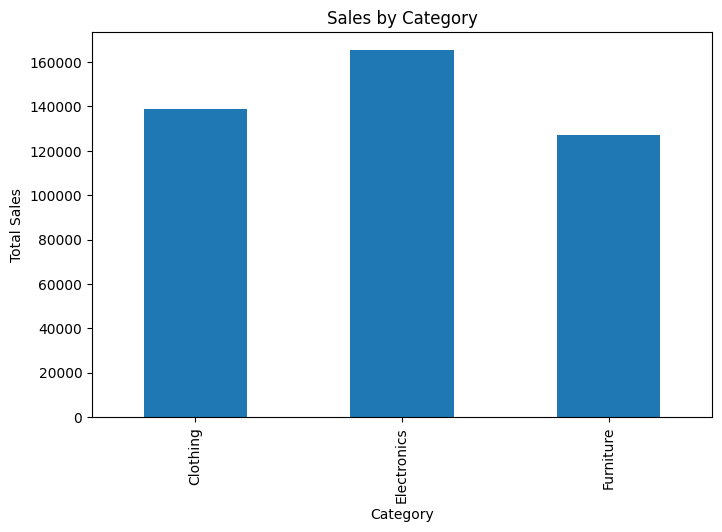

In [27]:
import matplotlib.pyplot as plt

# Calculate sales by category
sales_by_category = (
    main_df.groupby("Category")["Amount"]
    .sum()
)

# Display values
print(sales_by_category)

# Create bar chart
sales_by_category.plot(
    kind="bar",
    figsize=(8, 5)
)

# Chart title and labels
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Show chart
plt.show()

# *Profit by Category*

Category
Clothing       11163.0
Electronics    10494.0
Furniture       2298.0
Name: Profit, dtype: float64


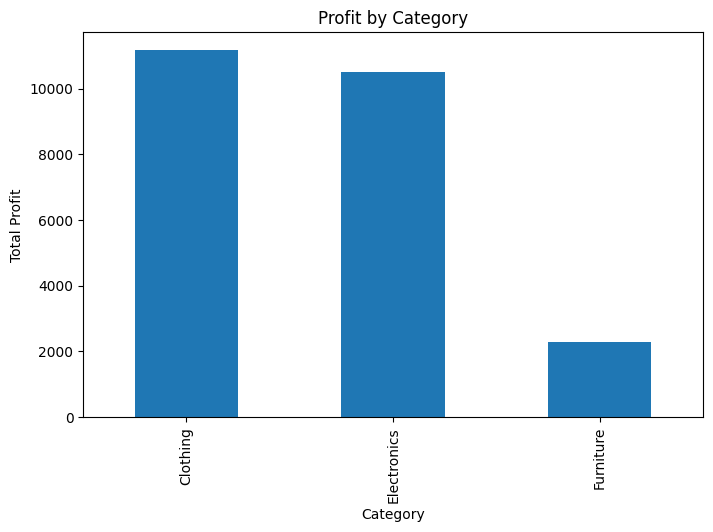

In [28]:
# Calculate profit by category
profit_by_category = (
    main_df.groupby("Category")["Profit"]
    .sum()
)

# Display values
print(profit_by_category)

# Create bar chart
profit_by_category.plot(
    kind="bar",
    figsize=(8, 5)
)

# Chart title and labels
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

# Show chart
plt.show()

# *Monthly Sales Trend*

Month
January      61439.0
March        58937.0
November     48086.0
February     38424.0
December     37579.0
April        32726.0
October      31615.0
August       30899.0
May          28545.0
September    26628.0
June         23658.0
July         12966.0
Name: Amount, dtype: float64


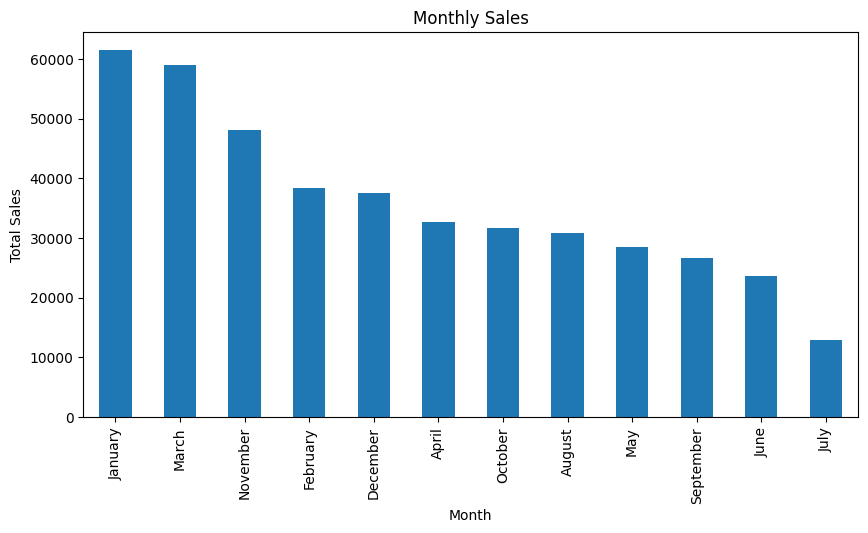

In [29]:
# Calculate monthly sales
monthly_sales = (
    main_df.groupby("Month")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Display values
print(monthly_sales)

# Create bar chart
monthly_sales.plot(
    kind="bar",
    figsize=(10, 5)
)

# Chart title and labels
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

# Show chart
plt.show()

# *Top States by Sales*

State
Madhya Pradesh       105140.0
Maharashtra           95348.0
Delhi                 22531.0
Uttar Pradesh         22359.0
Rajasthan             21149.0
Gujarat               21058.0
Punjab                16786.0
Karnataka             15058.0
West Bengal           14086.0
Kerala                13459.0
Andhra Pradesh        13256.0
Bihar                 12943.0
Nagaland              11903.0
Jammu and Kashmir     10829.0
Haryana                8863.0
Himachal Pradesh       8666.0
Goa                    6705.0
Tamil Nadu             6087.0
Sikkim                 5276.0
Name: Amount, dtype: float64


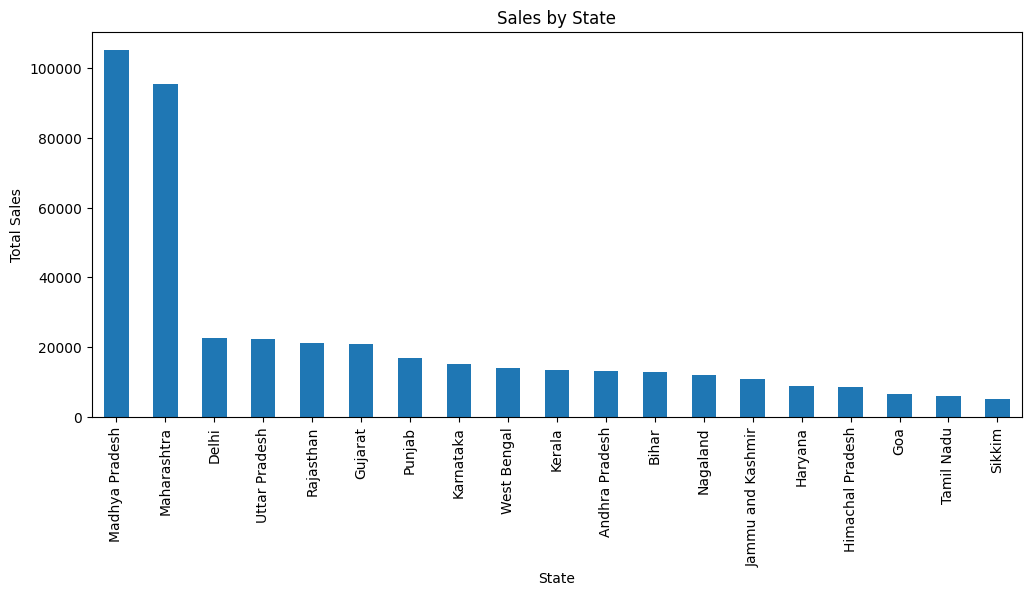

In [30]:
# Calculate sales by state
sales_by_state = (
    main_df.groupby("State")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Display values
print(sales_by_state)

# Create bar chart
sales_by_state.plot(
    kind="bar",
    figsize=(12, 5)
)

# Chart title and labels
plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")

# Show chart
plt.show()

# Machine Learning

# *Feature Selection & Target Selection*

In [31]:
# Select features
X = main_df[
    [
        "Amount",
        "Quantity",
        "Category",
        "Sub-Category",
        "State",
        "Month"
    ]
]

# Select target
y = main_df["Profit"]

# Display features
print("Features:")
print(X.head())

# Display target
print("\nTarget:")
print(y.head())

Features:
   Amount  Quantity     Category      Sub-Category        State  Month
0  1275.0         7    Furniture         Bookcases      Gujarat  April
1    66.0         5     Clothing             Stole      Gujarat  April
2     8.0         3     Clothing       Hankerchief      Gujarat  April
3    80.0         4  Electronics  Electronic Games      Gujarat  April
4   168.0         2  Electronics            Phones  Maharashtra  April

Target:
0   -1148.0
1     -12.0
2      -2.0
3     -56.0
4    -111.0
Name: Profit, dtype: float64


# *Encoding*

In [32]:
# Apply One-Hot Encoding

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

# Display shape after encoding
print("Encoded Shape:")
print(X_encoded.shape)

# Display first rows
print("\nEncoded Features:")
print(X_encoded.head())

Encoded Shape:
(1500, 49)

Encoded Features:
   Amount  Quantity  Category_Electronics  Category_Furniture  \
0  1275.0         7                 False                True   
1    66.0         5                 False               False   
2     8.0         3                 False               False   
3    80.0         4                  True               False   
4   168.0         2                  True               False   

   Sub-Category_Bookcases  Sub-Category_Chairs  Sub-Category_Electronic Games  \
0                    True                False                          False   
1                   False                False                          False   
2                   False                False                          False   
3                   False                False                           True   
4                   False                False                          False   

   Sub-Category_Furnishings  Sub-Category_Hankerchief  Sub-Category_Kurti  \


# *Train-Test Split*

In [33]:
from sklearn.model_selection import train_test_split

# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1200, 49)
X_test Shape: (300, 49)

y_train Shape: (1200,)
y_test Shape: (300,)


# *Training Linear Regression Model*

In [34]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test)

# Display first predictions
print("Predicted Values:")
print(y_pred[:5])

print("\nActual Values:")
print(y_test[:5].values)

Predicted Values:
[ 350.90019715   10.85088985  -18.47615446 -117.61291775  -56.56154861]

Actual Values:
[1698.   90.   -3.  -15.    0.]


# *Model Evaluation*

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

# Display results
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 78.08848025046808
MSE: 24783.325577732772
R2 Score: 0.2758436047726055


# Scaling Experiment

In [40]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Scaled X_train Shape:", X_train_scaled.shape)
print("Scaled X_test Shape:", X_test_scaled.shape)

Scaled X_train Shape: (1200, 49)
Scaled X_test Shape: (300, 49)


# *Training Linear Regression on Scaled Data*

In [41]:
# Create Linear Regression model
scaled_lr_model = LinearRegression()

# Train model on scaled data
scaled_lr_model.fit(
    X_train_scaled,
    y_train
)

# Predict on test data
scaled_pred = scaled_lr_model.predict(
    X_test_scaled
)

# Display predictions
print("Predicted Values:")
print(scaled_pred[:5])

print("\nActual Values:")
print(y_test[:5].values)

Predicted Values:
[ 350.90019715   10.85088985  -18.47615446 -117.61291775  -56.56154861]

Actual Values:
[1698.   90.   -3.  -15.    0.]


In [42]:
# Evaluate scaled Linear Regression model

scaled_mae = mean_absolute_error(
    y_test,
    scaled_pred
)

scaled_mse = mean_squared_error(
    y_test,
    scaled_pred
)

scaled_r2 = r2_score(
    y_test,
    scaled_pred
)

# Display results
print("Scaled MAE:", scaled_mae)
print("Scaled MSE:", scaled_mse)
print("Scaled R2 Score:", scaled_r2)

Scaled MAE: 78.08848025046801
Scaled MSE: 24783.325577732798
Scaled R2 Score: 0.27584360477260483


In [43]:
# Export final dataset to CSV file

main_df.to_csv(
    "ecommerce_final_dataset.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!


In [44]:
# Final validation for exported dataset

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

# Shape
print("\nDataset Shape:")
print(main_df.shape)

# Columns
print("\nColumns:")
print(main_df.columns.tolist())

# Data Types
print("\nData Types:")
print(main_df.dtypes)

# Missing Values
print("\nMissing Values:")
print(main_df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:")
print(main_df.duplicated().sum())

# First 5 Rows
print("\nFirst 5 Rows:")
print(main_df.head())

# Statistical Summary
print("\nStatistical Summary:")
print(main_df.describe())

FINAL DATASET VALIDATION

Dataset Shape:
(1500, 15)

Columns:
['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'Month', 'Profit Margin', 'Average Item Price', 'Customer Total Spending', 'High Profit Flag']

Data Types:
Order ID                           object
Order Date                 datetime64[ns]
CustomerName                       object
State                              object
City                               object
Amount                            float64
Profit                            float64
Quantity                            int64
Category                           object
Sub-Category                       object
Month                              object
Profit Margin                     float64
Average Item Price                float64
Customer Total Spending           float64
High Profit Flag                    int64
dtype: object

Missing Values:
Order ID                   0
Order Date          